Import required libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

loading dataset 

In [13]:
df1 = pd.read_csv("world-happiness-report.csv")
df= pd.read_csv("world-happiness-report-2021.csv")

In [14]:
df.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


Removing noisy columns from the dataset and keeping it clean

In [17]:
cols_to_keep = ['Country name', 'Regional indicator', 'Ladder score', 
                'Logged GDP per capita', 'Social support', 
                'Healthy life expectancy', 'Freedom to make life choices', 
                'Generosity', 'Perceptions of corruption']

In [18]:
df = df[cols_to_keep]

New and clean dataframe df

In [20]:
df.head()

,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.842,10.775,0.954,72.0,0.949,-0.098,0.186
1,Denmark,Western Europe,7.620,10.933,0.954,72.7,0.946,0.030,0.179
2,Switzerland,Western Europe,7.571,11.117,0.942,74.4,0.919,0.025,0.292
3,Iceland,Western Europe,7.554,10.878,0.983,73.0,0.955,0.160,0.673
4,Netherlands,Western Europe,7.464,10.932,0.942,72.4,0.913,0.175,0.338


`Business questions`
- Which country is the happiest and has highest ladder score
- What are features that affect the happiness of the country the most
- Does gdp of the country is the biggest factor that impact happiness or something else
- Is there are some regional patterns
- Does health and social support relate to happinessz
- Does corruption affects the GDP of the country
- Freedom to make life choices and decision affects an individual's life happiness

#### Observation 
- Dataset contains 149 rows and 9 columns
- 2 object datatypes and 7 float datatypes
- No missing values found

In [26]:
df.shape

(149, 9)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  149 non-null    object 
 1   Regional indicator            149 non-null    object 
 2   Ladder score                  149 non-null    float64
 3   Logged GDP per capita         149 non-null    float64
 4   Social support                149 non-null    float64
 5   Healthy life expectancy       149 non-null    float64
 6   Freedom to make life choices  149 non-null    float64
 7   Generosity                    149 non-null    float64
 8   Perceptions of corruption     149 non-null    float64
dtypes: float64(7), object(2)
memory usage: 10.6+ KB


#### Key insights
- Generosity shows unusual growth of the number from 0.07 to 0.54
- Mean of ladder score is 5.53 and min life expectency is 48 which is very low for any country 

In [25]:
df.describe()

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.532839,9.432208,0.814745,64.992799,0.791597,-0.015134,0.727450
std,1.073924,1.158601,0.114889,6.762043,0.113332,0.150657,0.179226
min,2.523000,6.635000,0.463000,48.478000,0.382000,-0.288000,0.082000
25%,4.852000,8.541000,0.750000,59.802000,0.718000,-0.126000,0.667000
50%,5.534000,9.569000,0.832000,66.603000,0.804000,-0.036000,0.781000
75%,6.255000,10.421000,0.905000,69.600000,0.877000,0.079000,0.845000
max,7.842000,11.647000,0.983000,76.953000,0.970000,0.542000,0.939000


In [27]:
df.isnull().sum()

Country name                    0
Regional indicator              0
Ladder score                    0
Logged GDP per capita           0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [41]:
df['Regional indicator'].value_counts()

Regional indicator
Sub-Saharan Africa                    36
Western Europe                        21
Latin America and Caribbean           20
Central and Eastern Europe            17
Middle East and North Africa          17
Commonwealth of Independent States    12
Southeast Asia                         9
South Asia                             7
East Asia                              6
North America and ANZ                  4
Name: count, dtype: int64

## Univariate analysis

> Generosity (1.01) and Perceptions of corruption (-1.58) have significant skewness beyond ±1 threshold. These two features may need log or sqrt transformation before ML modelling. All other features are within acceptable range."

In [61]:
df.select_dtypes(include='number').skew().round(2)

Ladder score                   -0.10
Logged GDP per capita          -0.35
Social support                 -0.94
Healthy life expectancy        -0.52
Freedom to make life choices   -0.75
Generosity                      1.01
Perceptions of corruption      -1.58
dtype: float64

Histogram for Generosity 
- Observed right skewed histogram 

<Axes: xlabel='Generosity', ylabel='Count'>

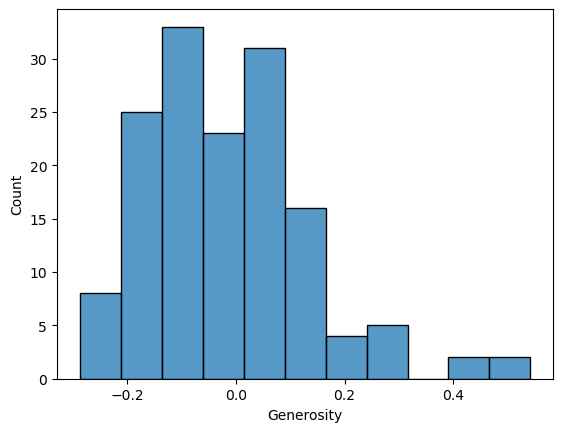

In [63]:
sns.histplot(df, x='Generosity')

Histogram for Perceptions of corruption
- heavily left skewed

<Axes: xlabel='Perceptions of corruption', ylabel='Count'>

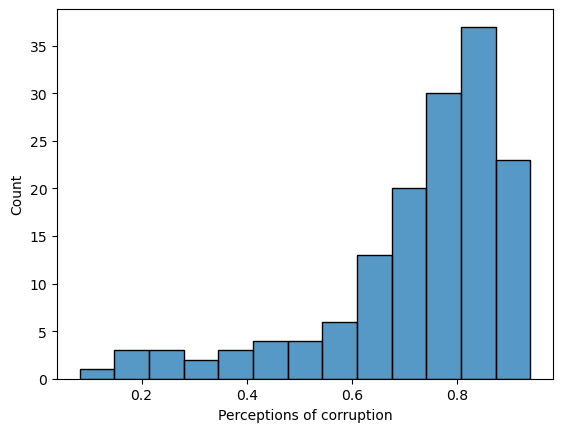

In [64]:
sns.histplot(df, x='Perceptions of corruption')

## Bivariate analysis

#### Top 10 highest ladder score countries

In [65]:
df.nlargest(10, 'Ladder score')[['Country name', 'Ladder score']]

,Country name,Ladder score
0,Finland,7.842
1,Denmark,7.620
2,Switzerland,7.571
3,Iceland,7.554
4,Netherlands,7.464
5,Norway,7.392
6,Sweden,7.363
7,Luxembourg,7.324
8,New Zealand,7.277
9,Austria,7.268


#### Which region has best Ladder score

In [66]:
# Happiness by region
df.groupby('Regional indicator')['Ladder score'].mean().round(2).sort_values(ascending=False)

Regional indicator
North America and ANZ                 7.13
Western Europe                        6.91
Central and Eastern Europe            5.98
Latin America and Caribbean           5.91
East Asia                             5.81
Commonwealth of Independent States    5.47
Southeast Asia                        5.41
Middle East and North Africa          5.22
Sub-Saharan Africa                    4.49
South Asia                            4.44
Name: Ladder score, dtype: float64

#### Correlation of target variable(ladder score) with all numerical columns and ploting heatmap 

In [ ]:
df.corr(numeric_only=True)['Ladder score'].round(2).sort_values(ascending=False)

Ladder score                    1.00
Logged GDP per capita           0.79
Healthy life expectancy         0.77
Social support                  0.76
Freedom to make life choices    0.61
Generosity                     -0.02
Perceptions of corruption      -0.42
Name: Ladder score, dtype: float64

<Axes: >

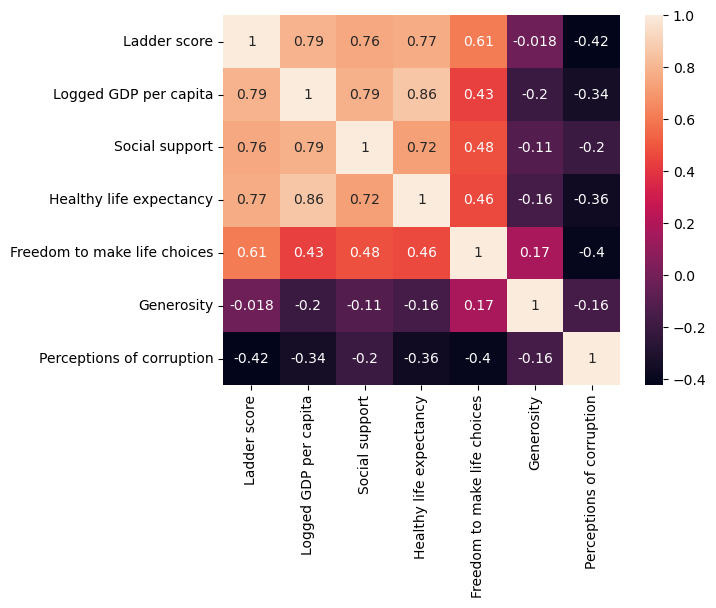

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#### Scatter plot of most correlated column with target column

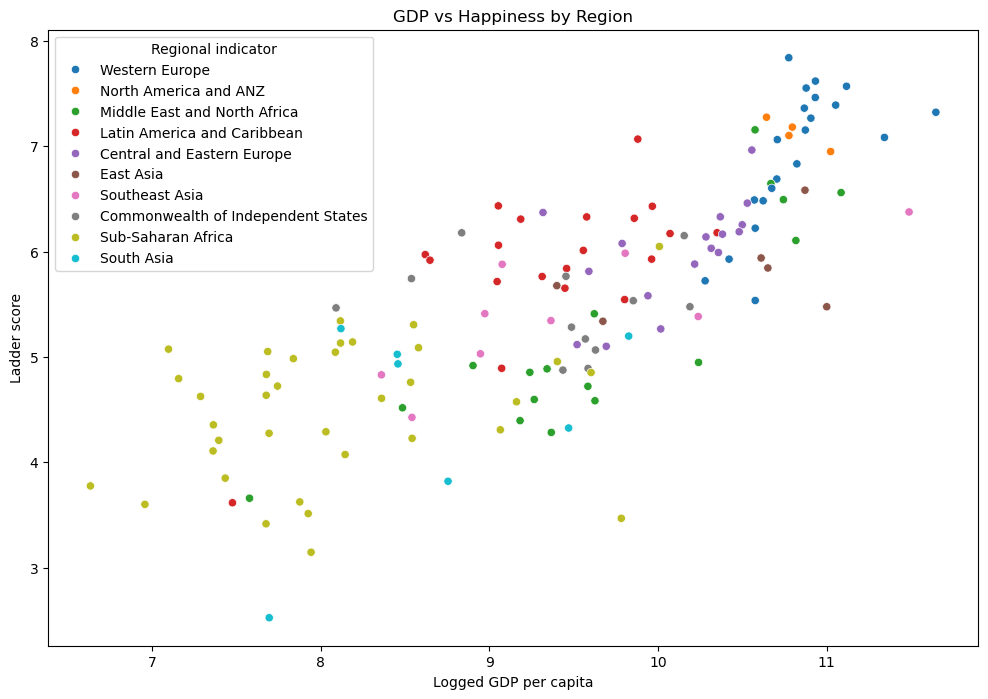

In [77]:
plt.figure(figsize=(12, 8))
sns.scatterplot(df, x='Logged GDP per capita', y='Ladder score', hue='Regional indicator')
plt.title('GDP vs Happiness by Region')
plt.show()

# Conclusion